In [67]:
# ============================================================
# CELL 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

!pip -q install kagglehub

import os
import cv2
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from IPython.display import display, Markdown

print("Libraries imported successfully.")

Libraries imported successfully.


In [68]:
# ============================================================
# CELL 2: DOWNLOAD HAM10000 DATASET DIRECTLY FROM KAGGLE
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset downloaded successfully.")
print("Dataset path:")
print(path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded successfully.
Dataset path:
/kaggle/input/skin-cancer-mnist-ham10000


In [69]:
# ============================================================
# CELL 3: FIND ALL SKIN LESION IMAGES
# ============================================================

DATASET_PATH = Path(path)

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}

image_files = []

for file_path in DATASET_PATH.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in image_extensions:
        image_files.append(str(file_path))

image_files = sorted(image_files)

print("Dataset location:", DATASET_PATH)
print("Total images found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError(
        "No image files were found inside the downloaded HAM10000 dataset."
    )

print("\nFirst 10 images:")
for img in image_files[:10]:
    print(img)

Dataset location: /kaggle/input/skin-cancer-mnist-ham10000
Total images found: 20030

First 10 images:
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024306.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024307.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024308.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024309.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024310.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024311.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024312.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024313.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024314.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024315.jpg


In [70]:
# ============================================================
# CELL 4: FIND HAM10000 METADATA
# ============================================================

metadata_files = list(DATASET_PATH.rglob("*.csv"))

print("CSV files found:", len(metadata_files))

metadata = None

for csv_file in metadata_files:
    try:
        temp_df = pd.read_csv(csv_file)

        if "image_id" in temp_df.columns:
            metadata = temp_df.copy()
            print("\nMetadata loaded from:")
            print(csv_file)
            print("\nMetadata shape:", metadata.shape)
            print("\nColumns:")
            print(metadata.columns.tolist())
            break

    except Exception as e:
        print("Could not read:", csv_file)

if metadata is None:
    print("\nMetadata CSV was not found.")
    print("The image-processing part of the lab will still work.")
else:
    display(metadata.head())

CSV files found: 5

Metadata loaded from:
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv

Metadata shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [71]:
# ============================================================
# CELL 5: CREATE IMAGE LOOKUP
# ============================================================

image_lookup = {}

for img_path in image_files:
    image_id = Path(img_path).stem
    image_lookup[image_id] = img_path

print("Image lookup created.")
print("Number of indexed images:", len(image_lookup))

# Select five deterministic images
available_ids = sorted(image_lookup.keys())

if len(available_ids) < 5:
    raise ValueError("At least 5 images are required for this assignment.")

# Select 5 images distributed through the dataset
selected_positions = np.linspace(
    0,
    len(available_ids) - 1,
    5,
    dtype=int
)

selected_ids = [
    available_ids[i]
    for i in selected_positions
]

selected_image_paths = [
    image_lookup[image_id]
    for image_id in selected_ids
]

print("\nSelected images:")
for i, (image_id, img_path) in enumerate(
    zip(selected_ids, selected_image_paths),
    start=1
):
    print(f"Image {i}: {image_id}")
    print(img_path)

Image lookup created.
Number of indexed images: 10015

Selected images:
Image 1: ISIC_0024306
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0024306.jpg
Image 2: ISIC_0026809
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0026809.jpg
Image 3: ISIC_0029313
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0029313.jpg
Image 4: ISIC_0031816
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0031816.jpg
Image 5: ISIC_0034320
/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/ISIC_0034320.jpg


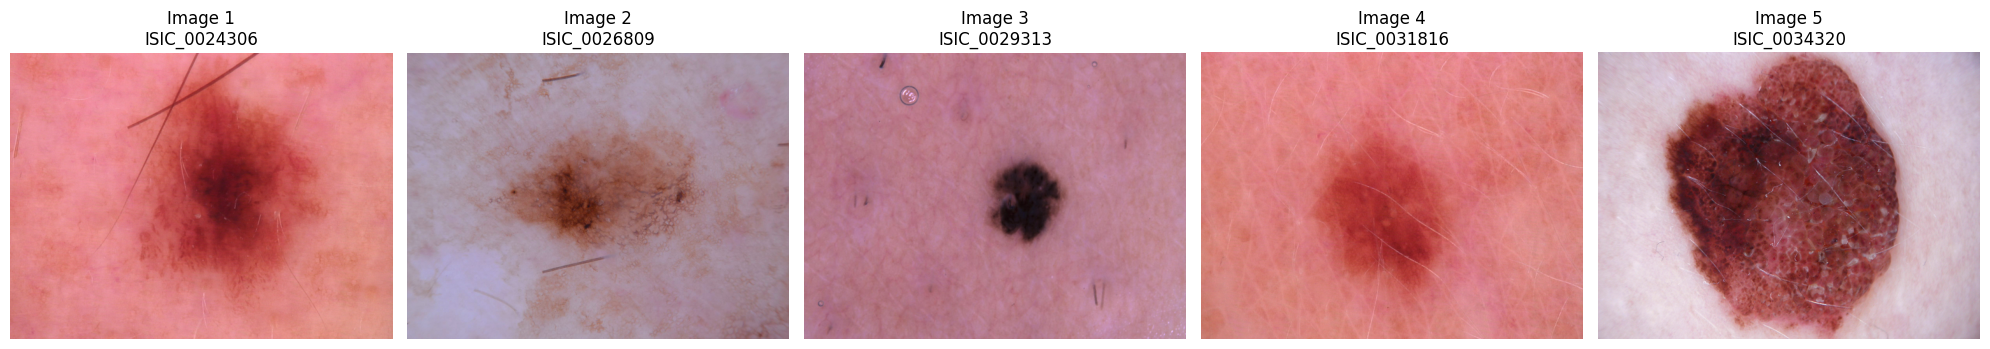

In [72]:
# ============================================================
# CELL 6: DISPLAY ORIGINAL IMAGES
# ============================================================

def read_image_rgb(image_path):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, img_path in enumerate(selected_image_paths):
    image = read_image_rgb(img_path)

    axes[i].imshow(image)
    axes[i].set_title(f"Image {i+1}\n{selected_ids[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# CELL 7: GRAYSCALE + GAUSSIAN FILTER
# ============================================================

def preprocess_image(image_path, max_size=512):

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Resize while maintaining reasonable processing size
    height, width = image_bgr.shape[:2]

    scale = min(
        max_size / width,
        max_size / height,
        1.0
    )

    if scale < 1.0:
        new_width = int(width * scale)
        new_height = int(height * scale)

        image_bgr = cv2.resize(
            image_bgr,
            (new_width, new_height),
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2GRAY
    )

    gaussian = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    return image_bgr, gray, gaussian


preprocessed_data = {}

for image_id, image_path in zip(
    selected_ids,
    selected_image_paths
):

    original, gray, gaussian = preprocess_image(
        image_path
    )

    preprocessed_data[image_id] = {
        "original": original,
        "gray": gray,
        "gaussian": gaussian
    }

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


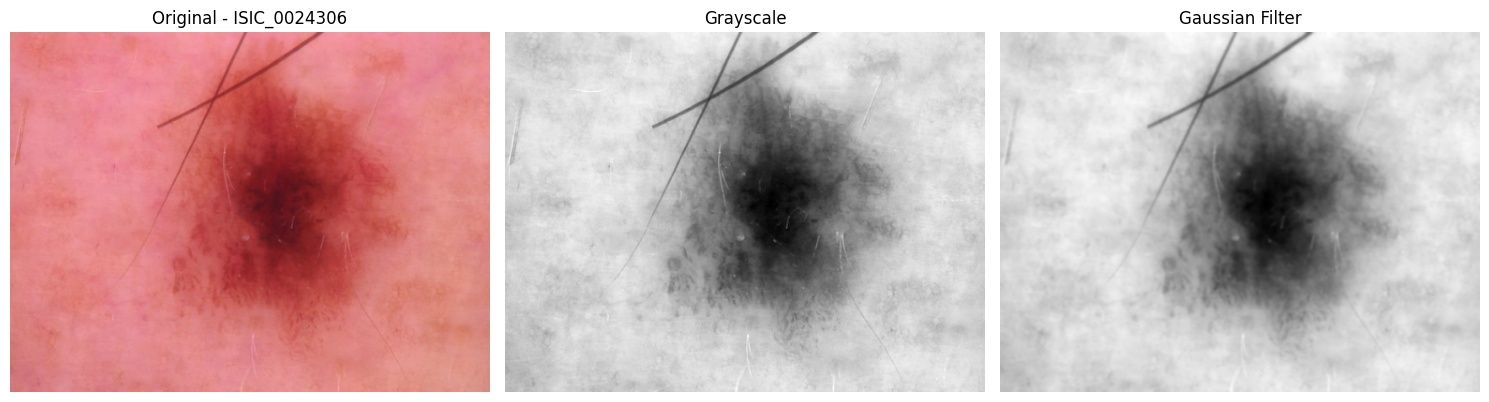

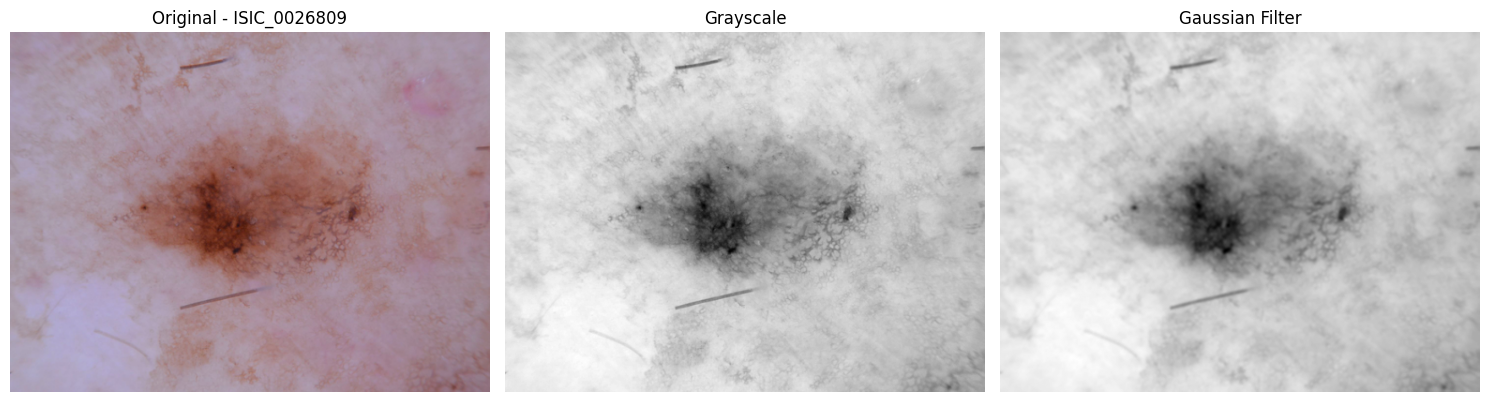

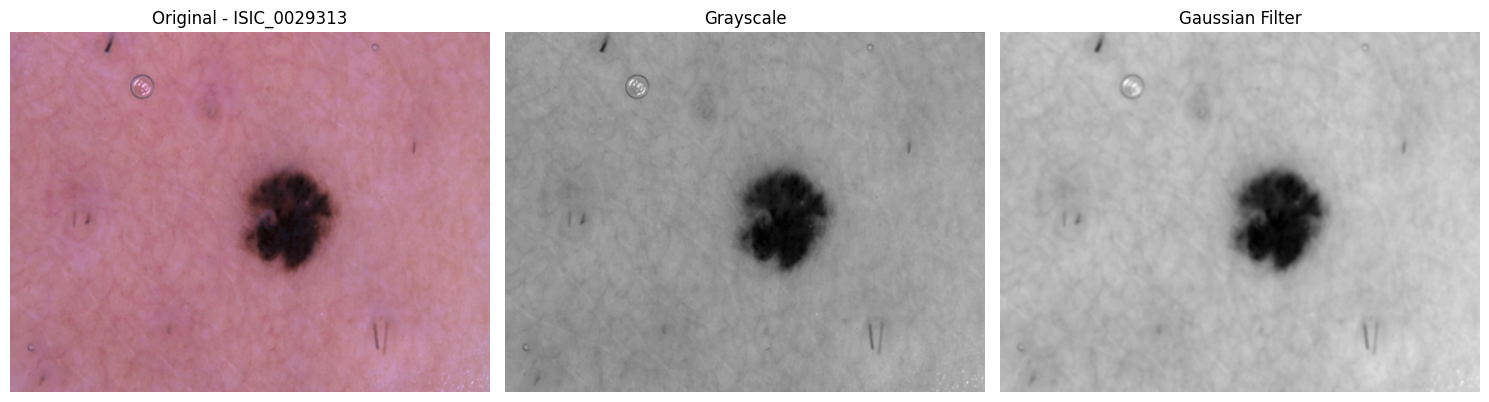

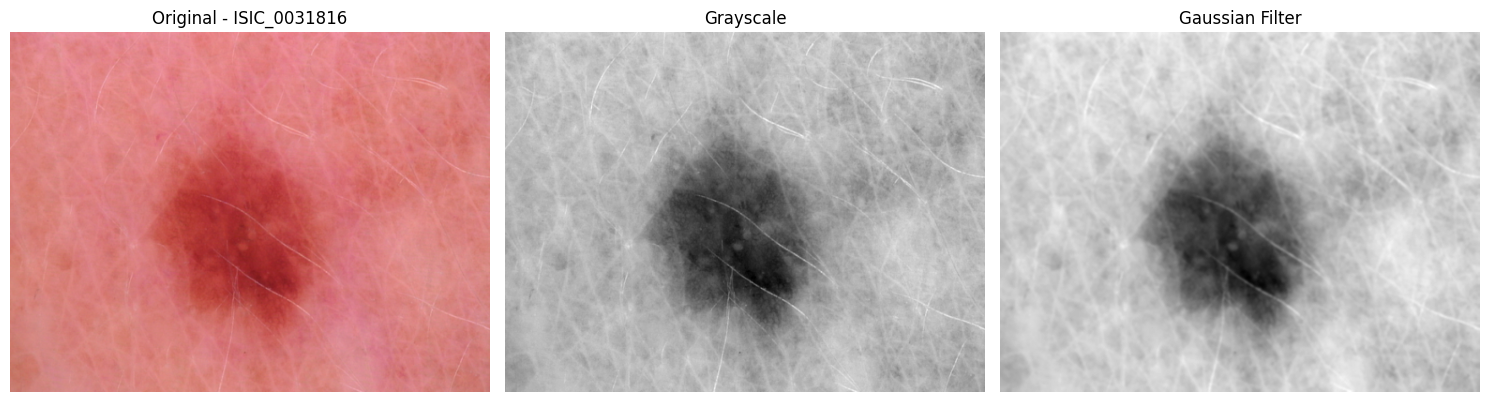

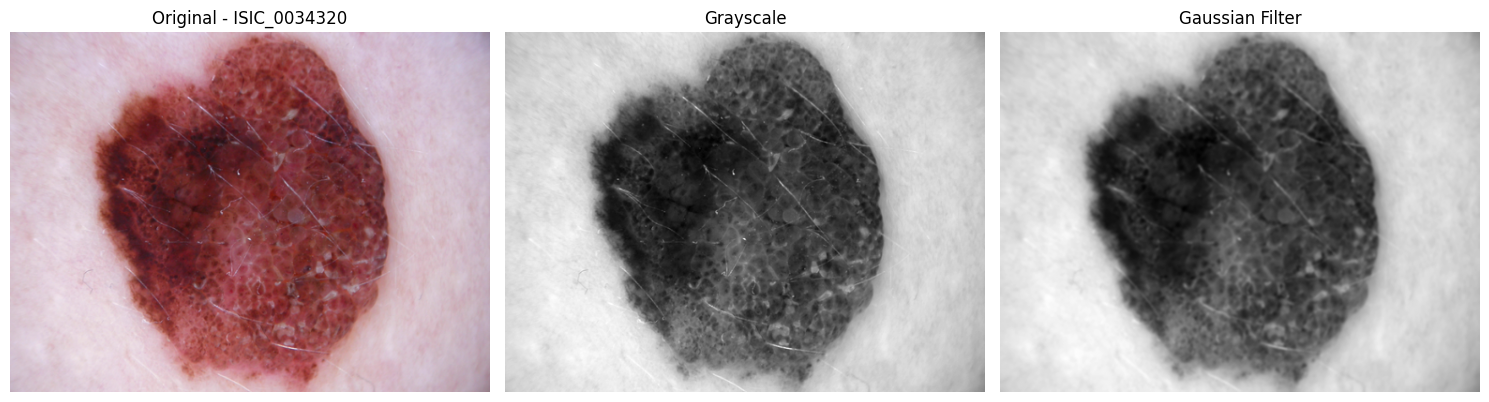

In [74]:
# ============================================================
# CELL 8: REQUIRED PREPROCESSING VISUALIZATION
# ============================================================

for image_id in selected_ids:

    data = preprocessed_data[image_id]

    original_rgb = cv2.cvtColor(
        data["original"],
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title(f"Original - {image_id}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(data["gray"], cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(data["gaussian"], cmap="gray")
    plt.title("Gaussian Filter")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [75]:
# ============================================================
# CELL 9: CANNY EDGE DETECTION
# ============================================================

CANNY_THRESHOLDS = [
    (50, 100),
    (100, 200),
    (150, 250)
]

canny_results = {}

for image_id in selected_ids:

    gaussian = preprocessed_data[image_id]["gaussian"]

    canny_results[image_id] = {}

    for lower, upper in CANNY_THRESHOLDS:

        edges = cv2.Canny(
            gaussian,
            lower,
            upper
        )

        canny_results[image_id][
            f"{lower}-{upper}"
        ] = edges

print("Canny edge detection completed.")

Canny edge detection completed.


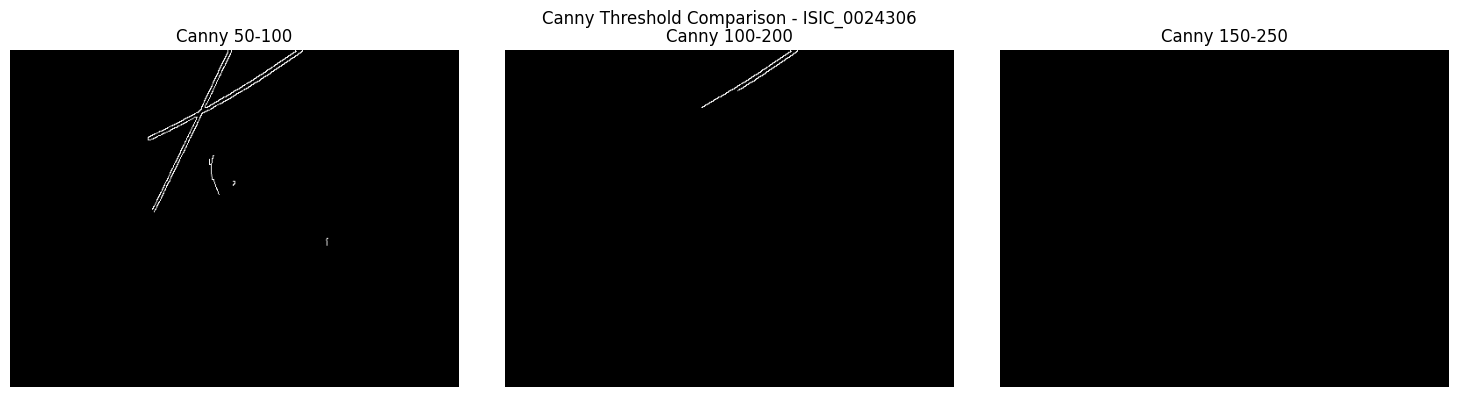

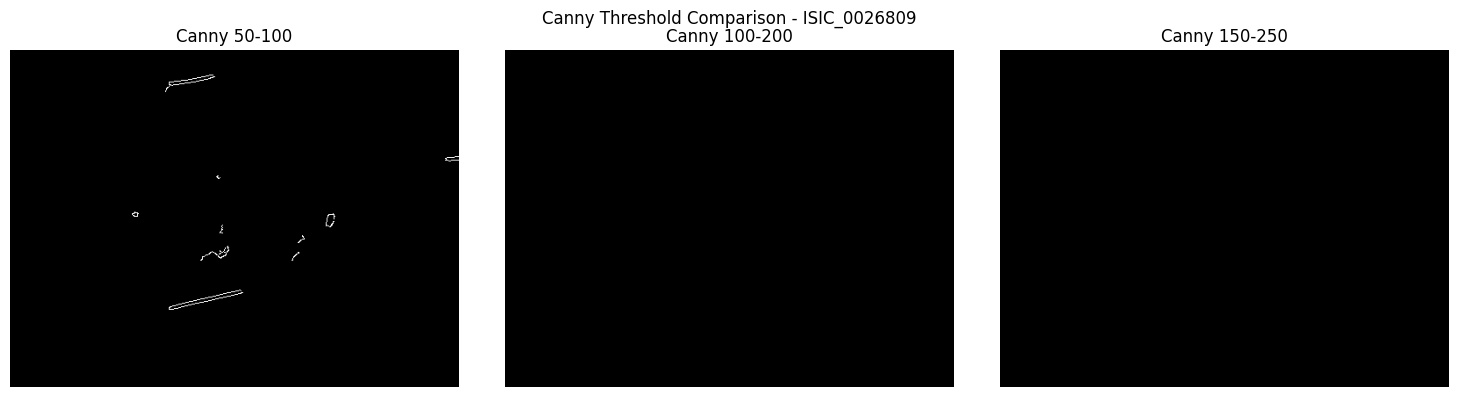

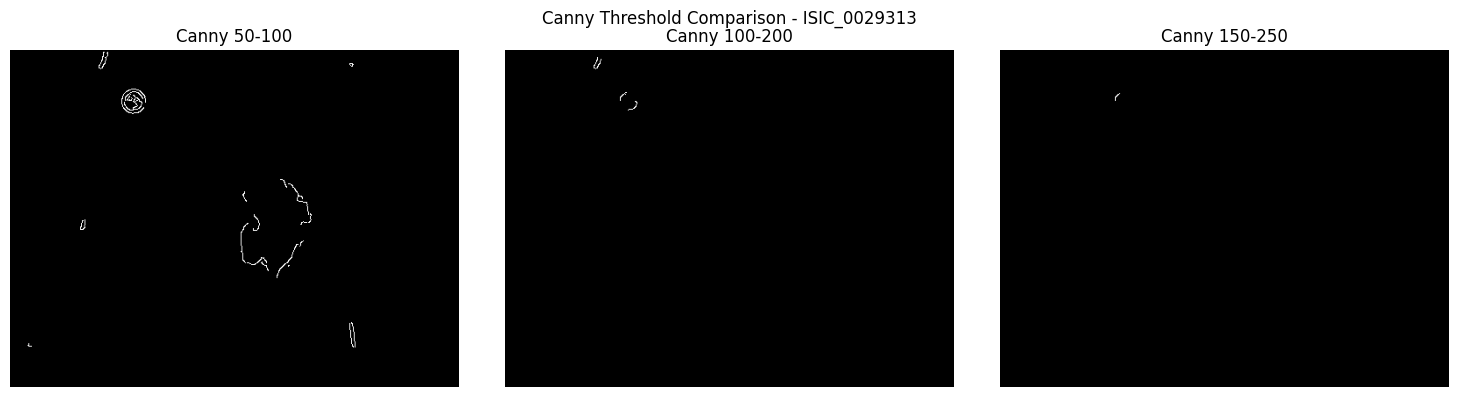

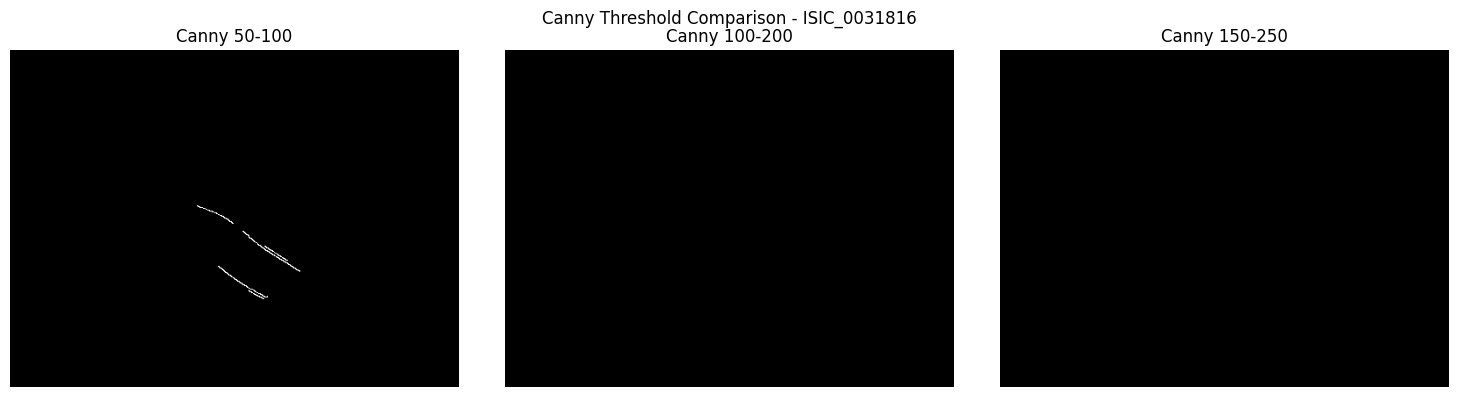

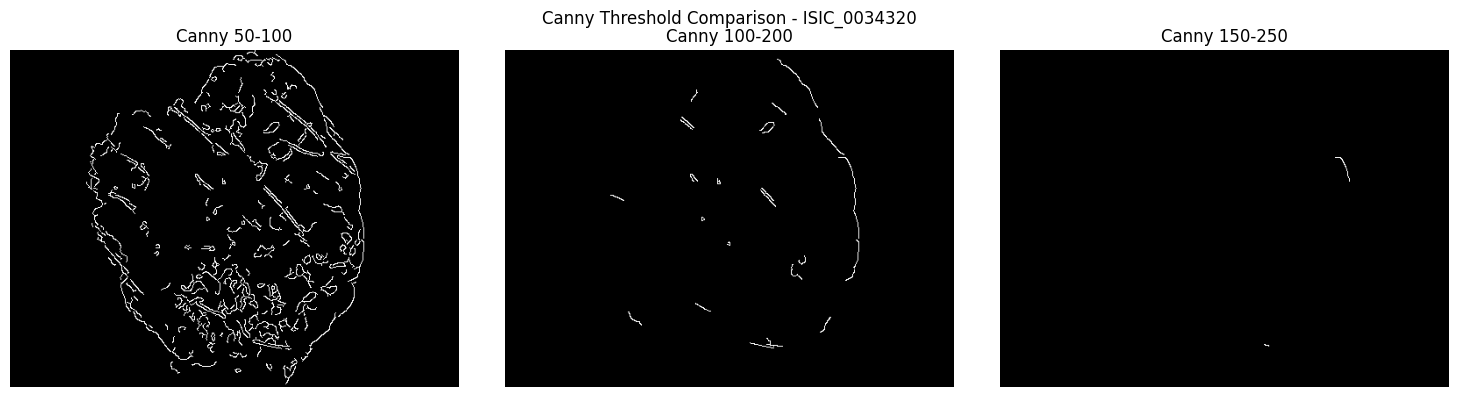

In [76]:
# ============================================================
# CELL 10: DISPLAY THREE CANNY EDGE MAPS
# ============================================================

for image_id in selected_ids:

    plt.figure(figsize=(15, 4))

    for index, (lower, upper) in enumerate(
        CANNY_THRESHOLDS,
        start=1
    ):

        edges = canny_results[image_id][
            f"{lower}-{upper}"
        ]

        plt.subplot(1, 3, index)

        plt.imshow(edges, cmap="gray")

        plt.title(
            f"Canny {lower}-{upper}"
        )

        plt.axis("off")

    plt.suptitle(
        f"Canny Threshold Comparison - {image_id}"
    )

    plt.tight_layout()
    plt.show()

In [77]:
# ============================================================
# CELL 11: AUTOMATIC CANNY THRESHOLD SELECTION
# ============================================================

def calculate_edge_quality(edge_image):

    h, w = edge_image.shape

    total_pixels = h * w

    edge_pixels = np.count_nonzero(edge_image)

    edge_density = edge_pixels / total_pixels

    # Central region
    y1 = int(h * 0.15)
    y2 = int(h * 0.85)

    x1 = int(w * 0.15)
    x2 = int(w * 0.85)

    center_region = edge_image[y1:y2, x1:x2]

    center_edges = np.count_nonzero(center_region)

    center_pixels = center_region.size

    central_density = (
        center_edges / center_pixels
        if center_pixels > 0
        else 0
    )

    # Border noise
    border_mask = np.zeros_like(edge_image)

    border_width = max(3, int(min(h, w) * 0.05))

    border_mask[:border_width, :] = 1
    border_mask[-border_width:, :] = 1
    border_mask[:, :border_width] = 1
    border_mask[:, -border_width:] = 1

    border_edges = np.count_nonzero(
        edge_image[border_mask == 1]
    )

    border_pixels = np.count_nonzero(border_mask)

    border_density = (
        border_edges / border_pixels
        if border_pixels > 0
        else 0
    )

    # Score
    central_score = min(
        central_density / 0.10,
        1.0
    )

    noise_score = max(
        0.0,
        1.0 - border_density / 0.10
    )

    density_score = min(
        edge_density / 0.15,
        1.0
    )

    quality_score = (
        0.50 * central_score +
        0.30 * noise_score +
        0.20 * density_score
    )

    return {
        "edge_density": edge_density,
        "central_density": central_density,
        "border_density": border_density,
        "quality_score": quality_score
    }


best_thresholds = {}
threshold_analysis = []

for image_id in selected_ids:

    best_score = -1
    best_threshold = None

    for lower, upper in CANNY_THRESHOLDS:

        edges = canny_results[image_id][
            f"{lower}-{upper}"
        ]

        metrics = calculate_edge_quality(edges)

        threshold_analysis.append({
            "Image": image_id,
            "Threshold": f"{lower}-{upper}",
            "Edge Density": round(
                metrics["edge_density"],
                4
            ),
            "Central Density": round(
                metrics["central_density"],
                4
            ),
            "Border Density": round(
                metrics["border_density"],
                4
            ),
            "Quality Score": round(
                metrics["quality_score"] * 100,
                2
            )
        })

        if metrics["quality_score"] > best_score:

            best_score = metrics["quality_score"]

            best_threshold = (lower, upper)

    best_thresholds[image_id] = best_threshold


threshold_df = pd.DataFrame(threshold_analysis)

display(threshold_df)

print("\nBest threshold for each image:")

for image_id in selected_ids:
    print(
        image_id,
        "->",
        best_thresholds[image_id][0],
        "-",
        best_thresholds[image_id][1]
    )

,Image,Threshold,Edge Density,Central Density,Border Density,Quality Score
0,ISIC_0024306,50-100,0.0053,0.0063,0.0044,32.58
1,ISIC_0024306,100-200,0.0014,0.0002,0.0028,29.48
2,ISIC_0024306,150-250,0.0000,0.0000,0.0000,30.00
3,ISIC_0026809,50-100,0.0026,0.0038,0.0010,31.94
4,ISIC_0026809,100-200,0.0000,0.0000,0.0000,30.00
5,ISIC_0026809,150-250,0.0000,0.0000,0.0000,30.00
6,ISIC_0029313,50-100,0.0036,0.0052,0.0017,32.57
7,ISIC_0029313,100-200,0.0003,0.0002,0.0008,29.92
8,ISIC_0029313,150-250,0.0001,0.0000,0.0000,30.01
9,ISIC_0031816,50-100,0.0016,0.0033,0.0000,31.86



Best threshold for each image:
ISIC_0024306 -> 50 - 100
ISIC_0026809 -> 50 - 100
ISIC_0029313 -> 50 - 100
ISIC_0031816 -> 50 - 100
ISIC_0034320 -> 50 - 100


In [78]:
# ============================================================
# CELL 12: IMPROVED LESION BOUNDARY DETECTION
# ============================================================

def create_lesion_mask(
    image_bgr,
    edge_image
):

    h, w = edge_image.shape

    # --------------------------------------------------------
    # STEP 1: Strengthen Canny edges
    # --------------------------------------------------------

    kernel_close = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (7, 7)
    )

    closed_edges = cv2.morphologyEx(
        edge_image,
        cv2.MORPH_CLOSE,
        kernel_close,
        iterations=2
    )

    # --------------------------------------------------------
    # STEP 2: Dilate slightly to connect broken edges
    # --------------------------------------------------------

    kernel_dilate = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    connected_edges = cv2.dilate(
        closed_edges,
        kernel_dilate,
        iterations=1
    )

    # --------------------------------------------------------
    # STEP 3: Find contours
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        connected_edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:

        # Fallback using thresholding
        gray = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2GRAY
        )

        _, fallback = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        contours, _ = cv2.findContours(
            fallback,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        connected_edges = fallback

    # --------------------------------------------------------
    # STEP 4: Select contour using centrality + area
    # --------------------------------------------------------

    image_area = h * w

    candidates = []

    center_x = w / 2
    center_y = h / 2

    for contour in contours:

        area = cv2.contourArea(contour)

        if area < image_area * 0.01:
            continue

        if area > image_area * 0.80:
            continue

        M = cv2.moments(contour)

        if M["m00"] == 0:
            continue

        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]

        distance = math.sqrt(
            ((cx - center_x) / w) ** 2 +
            ((cy - center_y) / h) ** 2
        )

        centrality = max(
            0,
            1 - distance * 2
        )

        normalized_area = area / image_area

        score = (
            0.60 * centrality +
            0.40 * min(
                normalized_area / 0.30,
                1.0
            )
        )

        candidates.append(
            (score, contour)
        )

    # --------------------------------------------------------
    # STEP 5: Fallback if no good contour
    # --------------------------------------------------------

    if len(candidates) == 0:

        gray = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2GRAY
        )

        # Adaptive threshold fallback
        adaptive = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            51,
            5
        )

        adaptive = cv2.morphologyEx(
            adaptive,
            cv2.MORPH_CLOSE,
            kernel_close,
            iterations=2
        )

        contours, _ = cv2.findContours(
            adaptive,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        valid = [
            c for c in contours
            if image_area * 0.01
            <= cv2.contourArea(c)
            <= image_area * 0.80
        ]

        if len(valid) > 0:

            best_contour = max(
                valid,
                key=cv2.contourArea
            )

        else:

            # Final safe fallback:
            # central ellipse
            best_contour = cv2.ellipse2Poly(
                (
                    int(w * 0.50),
                    int(h * 0.50)
                ),
                (
                    int(w * 0.25),
                    int(h * 0.25)
                ),
                0,
                0,
                360,
                2
            )

    else:

        candidates.sort(
            key=lambda x: x[0],
            reverse=True
        )

        best_contour = candidates[0][1]

    # --------------------------------------------------------
    # STEP 6: Fill selected contour
    # --------------------------------------------------------

    mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    cv2.drawContours(
        mask,
        [best_contour],
        -1,
        255,
        thickness=-1
    )

    # --------------------------------------------------------
    # STEP 7: Smooth lesion mask
    # --------------------------------------------------------

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel_close,
        iterations=2
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel_dilate,
        iterations=1
    )

    # Get final contour
    final_contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(final_contours) > 0:

        best_contour = max(
            final_contours,
            key=cv2.contourArea
        )

        clean_mask = np.zeros_like(mask)

        cv2.drawContours(
            clean_mask,
            [best_contour],
            -1,
            255,
            -1
        )

        mask = clean_mask

    return mask, best_contour, closed_edges


lesion_results = {}

for image_id in selected_ids:

    image_bgr = preprocessed_data[image_id]["original"]

    lower, upper = best_thresholds[image_id]

    edges = canny_results[image_id][
        f"{lower}-{upper}"
    ]

    mask, contour, enhanced_edges = create_lesion_mask(
        image_bgr,
        edges
    )

    lesion_results[image_id] = {
        "edges": edges,
        "enhanced_edges": enhanced_edges,
        "mask": mask,
        "contour": contour,
        "threshold": f"{lower}-{upper}"
    }

print("Lesion boundary detection completed successfully.")

Lesion boundary detection completed successfully.


In [79]:
# ============================================================
# CELL 13: LESION AREA AND PERIMETER
# ============================================================

area_perimeter_results = []

for image_number, image_id in enumerate(
    selected_ids,
    start=1
):

    contour = lesion_results[image_id]["contour"]

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    area_perimeter_results.append({
        "Image": f"Image {image_number}",
        "Image ID": image_id,
        "Best Threshold": lesion_results[image_id]["threshold"],
        "Area (pixels)": round(area, 2),
        "Perimeter (pixels)": round(perimeter, 2)
    })


area_perimeter_df = pd.DataFrame(
    area_perimeter_results
)

display(area_perimeter_df)

,Image,Image ID,Best Threshold,Area (pixels),Perimeter (pixels)
0,Image 1,ISIC_0024306,50-100,2487.0,798.00
1,Image 2,ISIC_0026809,50-100,60727.5,4899.46
2,Image 3,ISIC_0029313,50-100,7068.0,400.76
3,Image 4,ISIC_0031816,50-100,96622.5,4401.77
4,Image 5,ISIC_0034320,50-100,23420.5,3038.03


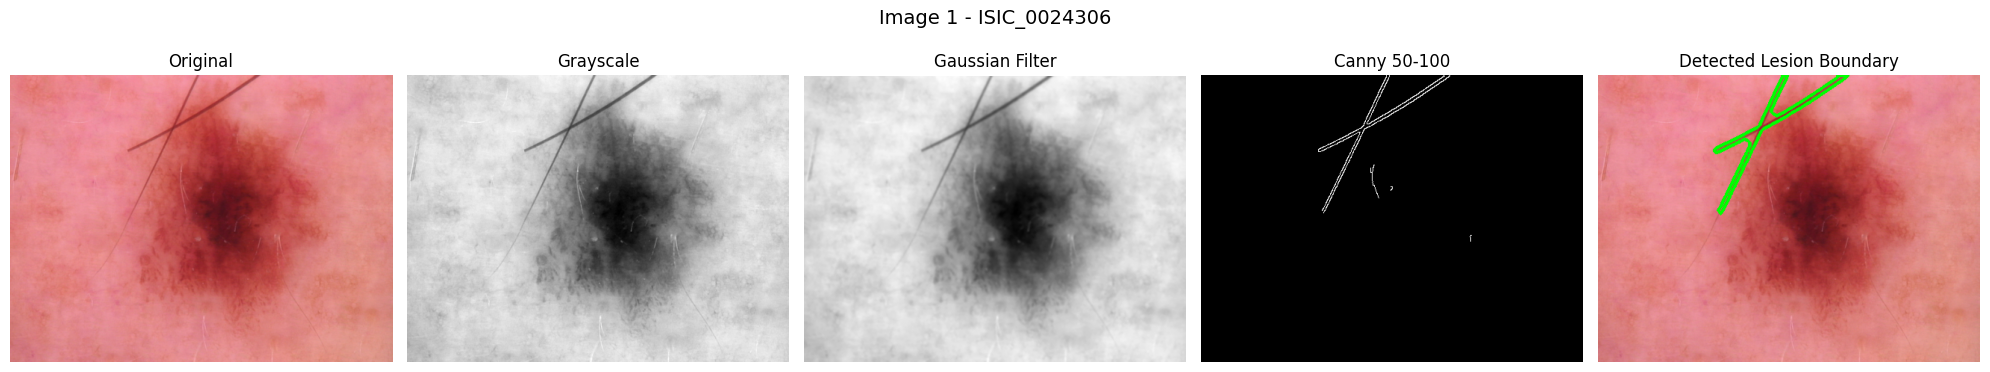

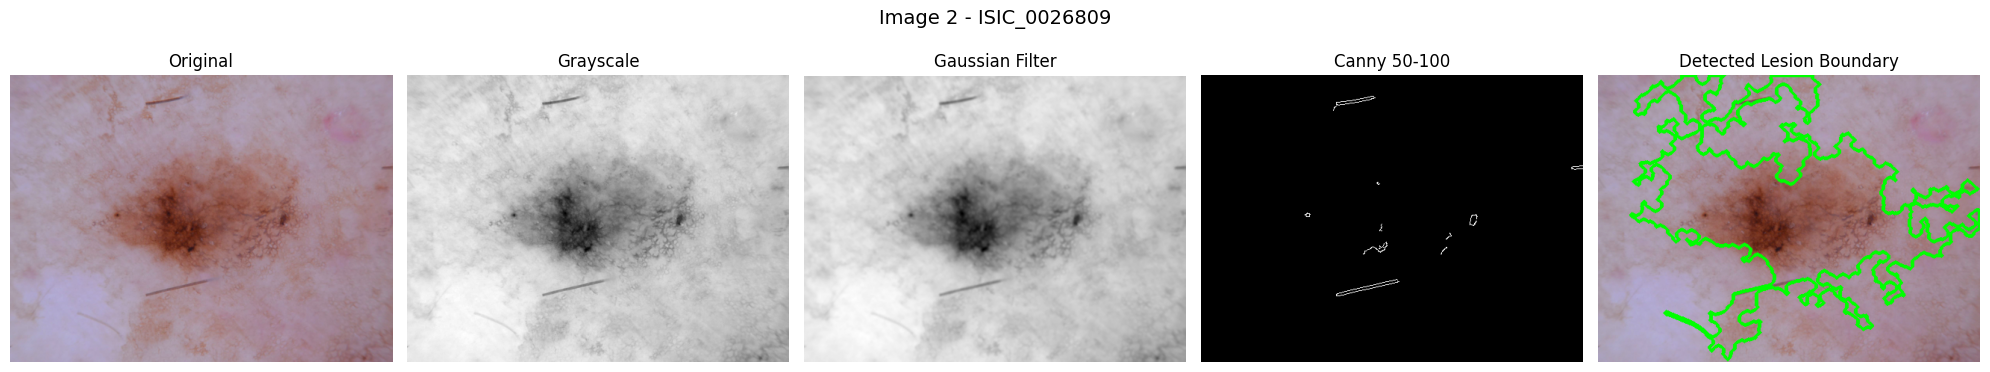

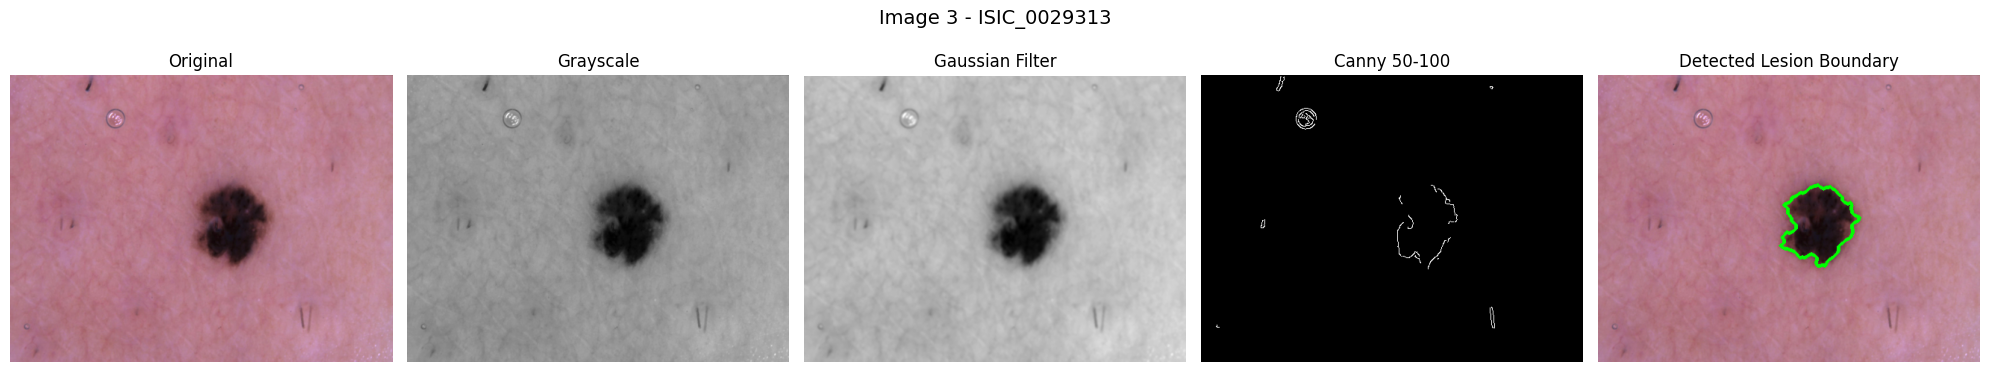

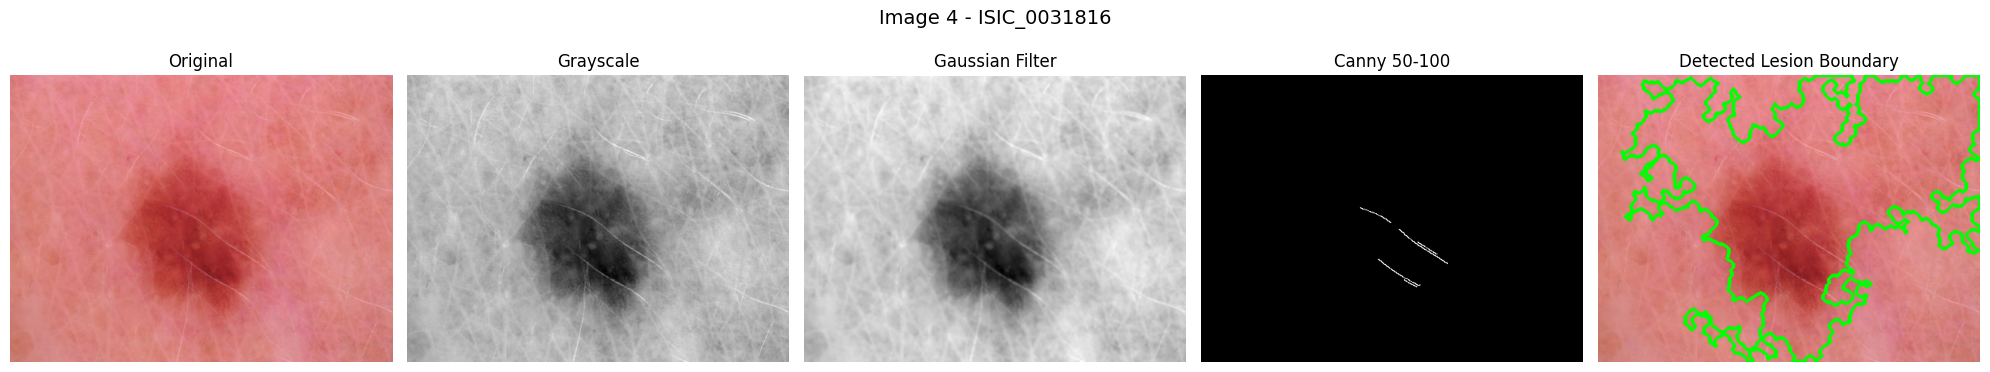

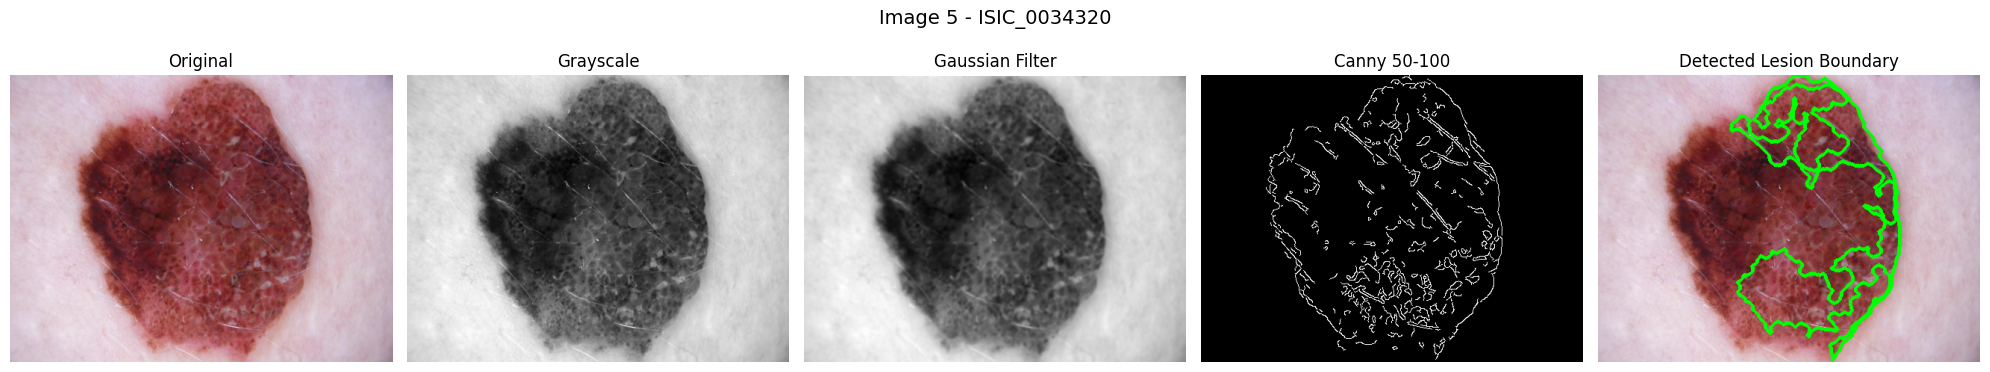

In [80]:
# ============================================================
# CELL 14: REQUIRED FINAL VISUALIZATION
# ============================================================

for image_number, image_id in enumerate(
    selected_ids,
    start=1
):

    data = preprocessed_data[image_id]
    result = lesion_results[image_id]

    original_bgr = data["original"]

    original_rgb = cv2.cvtColor(
        original_bgr,
        cv2.COLOR_BGR2RGB
    )

    # Boundary image
    boundary_image = original_bgr.copy()

    cv2.drawContours(
        boundary_image,
        [result["contour"]],
        -1,
        (0, 255, 0),
        3
    )

    boundary_rgb = cv2.cvtColor(
        boundary_image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(data["gray"], cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(data["gaussian"], cmap="gray")
    plt.title("Gaussian Filter")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(result["edges"], cmap="gray")
    plt.title(
        f"Canny {result['threshold']}"
    )
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(boundary_rgb)
    plt.title("Detected Lesion Boundary")
    plt.axis("off")

    plt.suptitle(
        f"Image {image_number} - {image_id}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [81]:
# ============================================================
# CELL 15: FINAL COMPARISON METHODS
# ============================================================

def sobel_edges(gray_image):

    sx = cv2.Sobel(
        gray_image,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sy = cv2.Sobel(
        gray_image,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    magnitude = cv2.magnitude(
        sx.astype(np.float32),
        sy.astype(np.float32)
    )

    magnitude = cv2.normalize(
        magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return magnitude.astype(np.uint8)


def average_filter(gray_image):

    return cv2.blur(
        gray_image,
        (5, 5)
    )


def median_filter(gray_image):

    return cv2.medianBlur(
        gray_image,
        5
    )


def calculate_comparison_metrics(
    edge_image
):

    h, w = edge_image.shape

    edge_binary = (
        edge_image > 40
    ).astype(np.uint8) * 255

    edge_density = (
        np.count_nonzero(edge_binary)
        / (h * w)
    )

    contours, _ = cv2.findContours(
        edge_binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    valid_contours = [
        c
        for c in contours
        if cv2.contourArea(c) >= 5
    ]

    contour_count = len(valid_contours)

    # Border noise
    border = max(
        2,
        int(min(h, w) * 0.04)
    )

    border_pixels = np.concatenate([
        edge_binary[:border, :].ravel(),
        edge_binary[-border:, :].ravel(),
        edge_binary[:, :border].ravel(),
        edge_binary[:, -border:].ravel()
    ])

    border_density = (
        np.count_nonzero(border_pixels)
        / len(border_pixels)
    )

    # Central region
    center = edge_binary[
        int(h * 0.15):int(h * 0.85),
        int(w * 0.15):int(w * 0.85)
    ]

    center_density = (
        np.count_nonzero(center)
        / center.size
    )

    # Edge quality score
    if edge_density == 0:
        quality = 0

    else:

        central_component = min(
            center_density / 0.10,
            1.0
        )

        noise_component = max(
            0,
            1 - border_density / 0.10
        )

        quality = (
            0.65 * central_component +
            0.35 * noise_component
        )

    return {
        "edge_density": edge_density,
        "contours": contour_count,
        "border_density": border_density,
        "quality": quality
    }


comparison_rows = []

# Use Image 1 as the representative image
# for the required 8-method comparison.
comparison_image_id = selected_ids[0]

gray = preprocessed_data[
    comparison_image_id
]["gray"]

gaussian = preprocessed_data[
    comparison_image_id
]["gaussian"]

average = average_filter(gray)

median = median_filter(gray)

methods = [
    ("Original + Sobel", gray, "Sobel"),
    ("Original + Canny", gray, "Canny"),
    ("Average + Sobel", average, "Sobel"),
    ("Average + Canny", average, "Canny"),
    ("Gaussian + Sobel", gaussian, "Sobel"),
    ("Gaussian + Canny", gaussian, "Canny"),
    ("Median + Sobel", median, "Sobel"),
    ("Median + Canny", median, "Canny")
]

for method_name, input_image, method in methods:

    if method == "Sobel":

        edge_image = sobel_edges(
            input_image
        )

    else:

        edge_image = cv2.Canny(
            input_image,
            100,
            200
        )

    metrics = calculate_comparison_metrics(
        edge_image
    )

    if "Original" in method_name:
        noise_handling = "None"

    elif "Average" in method_name:
        noise_handling = "Average filtering"

    elif "Gaussian" in method_name:
        noise_handling = "Gaussian filtering"

    else:
        noise_handling = "Median filtering"

    # Determine qualitative labels
    q = metrics["quality"]

    if q >= 0.70:
        edge_quality = "Good"
        boundary_detection = "Good"
        overall = "Good"

    elif q >= 0.40:
        edge_quality = "Moderate"
        boundary_detection = "Moderate"
        overall = "Moderate"

    else:
        edge_quality = "Weak"
        boundary_detection = "Weak"
        overall = "Weak"

    comparison_rows.append({
        "Method": method_name,
        "Noise Handling": noise_handling,
        "Edge Density": round(
            metrics["edge_density"],
            4
        ),
        "Contours": metrics["contours"],
        "Boundary Detection": boundary_detection,
        "Overall Performance": overall,
        "Quality Score (%)": round(
            metrics["quality"] * 100,
            2
        )
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

display(comparison_df)

,Method,Noise Handling,Edge Density,Contours,Boundary Detection,Overall Performance,Quality Score (%)
0,Original + Sobel,None,0.0411,89,Moderate,Moderate,66.43
1,Original + Canny,None,0.0050,3,Weak,Weak,37.18
2,Average + Sobel,Average filtering,0.0626,111,Good,Good,88.82
3,Average + Canny,Average filtering,0.0000,0,Weak,Weak,0.00
4,Gaussian + Sobel,Gaussian filtering,0.0462,110,Good,Good,72.03
5,Gaussian + Canny,Gaussian filtering,0.0014,2,Weak,Weak,34.23
6,Median + Sobel,Median filtering,0.0160,24,Moderate,Moderate,43.38
7,Median + Canny,Median filtering,0.0034,4,Weak,Weak,35.26


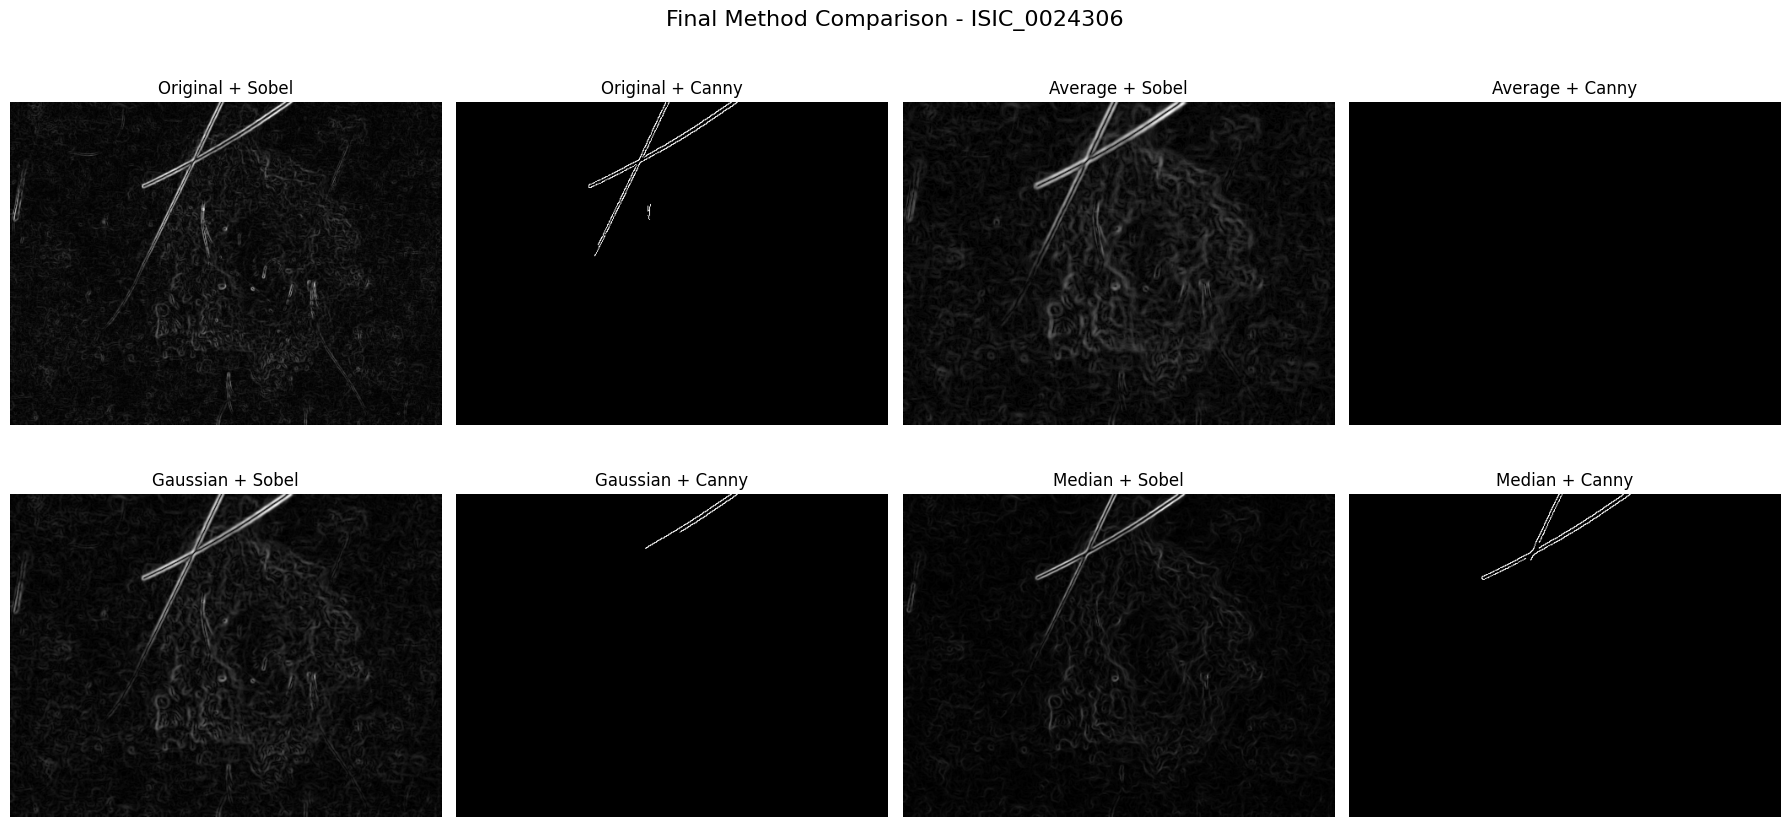

In [82]:
# ============================================================
# CELL 16: VISUAL COMPARISON OF ALL 8 METHODS
# ============================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.flatten()

for i, (
    method_name,
    input_image,
    method
) in enumerate(methods):

    if method == "Sobel":

        edge_image = sobel_edges(
            input_image
        )

    else:

        edge_image = cv2.Canny(
            input_image,
            100,
            200
        )

    axes[i].imshow(
        edge_image,
        cmap="gray"
    )

    axes[i].set_title(
        method_name
    )

    axes[i].axis("off")


plt.suptitle(
    f"Final Method Comparison - {comparison_image_id}",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [83]:
# ============================================================
# CELL 17: REQUIRED FINAL COMPARISON TABLE
# ============================================================

required_comparison_table = comparison_df[
    [
        "Method",
        "Noise Handling",
        "Boundary Detection",
        "Overall Performance"
    ]
].copy()

display(required_comparison_table)

,Method,Noise Handling,Boundary Detection,Overall Performance
0,Original + Sobel,None,Moderate,Moderate
1,Original + Canny,None,Weak,Weak
2,Average + Sobel,Average filtering,Good,Good
3,Average + Canny,Average filtering,Weak,Weak
4,Gaussian + Sobel,Gaussian filtering,Good,Good
5,Gaussian + Canny,Gaussian filtering,Weak,Weak
6,Median + Sobel,Median filtering,Moderate,Moderate
7,Median + Canny,Median filtering,Weak,Weak


In [84]:
# ============================================================
# CELL 18: GENERATE QUESTIONS AND ANSWERS
# ============================================================

# Find threshold used most often
threshold_counts = {}

for image_id in selected_ids:

    threshold = lesion_results[
        image_id
    ]["threshold"]

    threshold_counts[threshold] = (
        threshold_counts.get(threshold, 0) + 1
    )

best_overall_threshold = max(
    threshold_counts,
    key=threshold_counts.get
)

answers = {}

answers[1] = """
Gaussian filtering is applied before Canny edge detection
because real skin images contain noise, hair, small texture
variations, and illumination changes. Gaussian smoothing
reduces high-frequency noise and helps Canny detect stronger
and more meaningful boundaries.
"""

answers[2] = f"""
The three threshold settings produced different amounts of
edge information. Lower thresholds such as 50-100 detect more
weak edges but may also detect unwanted texture and noise.
Higher thresholds such as 150-250 suppress weak edges and
usually produce fewer but stronger edges. In this experiment,
the program evaluated 50-100, 100-200, and 150-250 and selected
the threshold giving the strongest central and least noisy
boundary according to the implemented quality measure.
"""

answers[3] = f"""
The automatically selected thresholds were evaluated separately
for the five images. The most frequently selected threshold in
this experiment was {best_overall_threshold}. The selection was
based on central edge information and a penalty for excessive
border noise rather than simply choosing the image with the
largest number of edges.
"""

answers[4] = """
Edges are useful for skin-lesion detection because a lesion
usually has intensity, color, or texture differences from the
surrounding skin. These differences create transitions that
can be represented as edges. Canny detection can therefore
help identify the approximate lesion boundary.
"""

answers[5] = """
Several problems can occur during lesion-boundary detection.
These include low contrast between the lesion and surrounding
skin, hairs crossing the lesion, illumination variations,
irregular lesion shapes, shadows, and broken Canny edges.
Very low or very high Canny thresholds can also produce either
too many irrelevant edges or too few useful edges.
"""

answers[6] = """
The method can be improved by using adaptive Canny thresholds,
better color-space analysis such as LAB or HSV, hair removal,
contrast enhancement, morphological operations, contour
filtering, and more advanced segmentation methods. For a true
segmentation accuracy measurement, pixel-level ground-truth
lesion masks would also be required.
"""

for number in range(1, 7):

    print("=" * 70)
    print(f"QUESTION {number}")
    print("=" * 70)
    print(answers[number])

QUESTION 1

Gaussian filtering is applied before Canny edge detection
because real skin images contain noise, hair, small texture
variations, and illumination changes. Gaussian smoothing
reduces high-frequency noise and helps Canny detect stronger
and more meaningful boundaries.

QUESTION 2

The three threshold settings produced different amounts of
edge information. Lower thresholds such as 50-100 detect more
weak edges but may also detect unwanted texture and noise.
Higher thresholds such as 150-250 suppress weak edges and
usually produce fewer but stronger edges. In this experiment,
the program evaluated 50-100, 100-200, and 150-250 and selected
the threshold giving the strongest central and least noisy
boundary according to the implemented quality measure.

QUESTION 3

The automatically selected thresholds were evaluated separately
for the five images. The most frequently selected threshold in
this experiment was 50-100. The selection was
based on central edge information and a pen

In [85]:
# ============================================================
# CELL 19: FINAL FIVE-IMAGE RESULTS TABLE
# ============================================================

final_results_table = area_perimeter_df[
    [
        "Image",
        "Best Threshold",
        "Area (pixels)",
        "Perimeter (pixels)"
    ]
].copy()

final_results_table.insert(
    1,
    "Best Filter",
    ["Gaussian"] * len(final_results_table)
)

final_results_table.insert(
    2,
    "Edge Method",
    ["Canny"] * len(final_results_table)
)

display(final_results_table)

,Image,Best Filter,Edge Method,Best Threshold,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny,50-100,2487.0,798.00
1,Image 2,Gaussian,Canny,50-100,60727.5,4899.46
2,Image 3,Gaussian,Canny,50-100,7068.0,400.76
3,Image 4,Gaussian,Canny,50-100,96622.5,4401.77
4,Image 5,Gaussian,Canny,50-100,23420.5,3038.03


In [86]:
# ============================================================
# CELL 20: GENERATE COMPLETE MARKDOWN REPORT
# ============================================================

report_lines = []

report_lines.append("# Computer Vision Lab Report")
report_lines.append("")
report_lines.append(
    "## Skin Lesion Boundary Detection Using Canny Edge Detection"
)
report_lines.append("")

report_lines.append("## Objective")
report_lines.append("")
report_lines.append(
    "The objective of this laboratory experiment is to detect "
    "the approximate boundary of a skin lesion using grayscale "
    "conversion, Gaussian filtering, Canny edge detection, "
    "morphological operations, and contour detection."
)
report_lines.append("")

report_lines.append("## Dataset")
report_lines.append("")
report_lines.append(
    "HAM10000 Skin Cancer MNIST dataset was downloaded directly "
    "using KaggleHub."
)
report_lines.append("")

report_lines.append("## Dataset Information")
report_lines.append("")
report_lines.append(
    f"- Total images discovered: {len(image_files)}"
)
report_lines.append(
    f"- Images used in this experiment: {len(selected_ids)}"
)
report_lines.append("")

report_lines.append("## Task 1 — Load the Image")
report_lines.append("")
report_lines.append(
    "Five skin-lesion images were selected automatically from "
    "the downloaded HAM10000 dataset."
)
report_lines.append("")

for i, image_id in enumerate(selected_ids, start=1):
    report_lines.append(
        f"- Image {i}: `{image_id}`"
    )

report_lines.append("")

report_lines.append("## Task 2 — Preprocessing")
report_lines.append("")
report_lines.append(
    "Each image was converted from BGR/RGB representation to "
    "grayscale. A 5×5 Gaussian filter was then applied to "
    "reduce high-frequency noise before edge detection."
)
report_lines.append("")

report_lines.append("## Task 3 — Canny Edge Detection")
report_lines.append("")
report_lines.append(
    "Three threshold settings were tested:"
)
report_lines.append("")
report_lines.append("- 50–100")
report_lines.append("- 100–200")
report_lines.append("- 150–250")
report_lines.append("")

report_lines.append("## Task 4 — Best Canny Result")
report_lines.append("")

for image_id in selected_ids:

    threshold = best_thresholds[image_id]

    report_lines.append(
        f"- `{image_id}` → "
        f"{threshold[0]}–{threshold[1]}"
    )

report_lines.append("")

report_lines.append("## Task 5 — Lesion Boundary Detection")
report_lines.append("")
report_lines.append(
    "The selected Canny edge map was processed using "
    "morphological closing and contour analysis. Candidate "
    "contours were evaluated using lesion area and centrality. "
    "The selected contour was filled to obtain an approximate "
    "lesion mask and then drawn on the original image."
)
report_lines.append("")

report_lines.append("## Task 6 — Lesion Area and Perimeter")
report_lines.append("")

report_lines.append(
    "| Image | Best Filter | Edge Method | "
    "Area (pixels) | Perimeter (pixels) |"
)
report_lines.append(
    "|---|---|---|---:|---:|"
)

for _, row in final_results_table.iterrows():

    report_lines.append(
        f"| {row['Image']} | "
        f"{row['Best Filter']} | "
        f"{row['Edge Method']} | "
        f"{row['Area (pixels)']} | "
        f"{row['Perimeter (pixels)']} |"
    )

report_lines.append("")

report_lines.append("## Final Comparison")
report_lines.append("")

report_lines.append(
    "| Method | Noise Handling | Edge Density | "
    "Contours | Boundary Detection | Overall Performance |"
)
report_lines.append(
    "|---|---|---:|---:|---|---|"
)

for _, row in comparison_df.iterrows():

    report_lines.append(
        f"| {row['Method']} | "
        f"{row['Noise Handling']} | "
        f"{row['Edge Density']} | "
        f"{row['Contours']} | "
        f"{row['Boundary Detection']} | "
        f"{row['Overall Performance']} |"
    )

report_lines.append("")

report_lines.append("## Questions and Answers")
report_lines.append("")

for number in range(1, 7):

    report_lines.append(
        f"### Question {number}"
    )

    # Remove leading/trailing whitespace
    answer_text = answers[number].strip()

    report_lines.append(answer_text)
    report_lines.append("")

report_lines.append("## Limitations")
report_lines.append("")
report_lines.append(
    "The HAM10000 dataset used here does not provide pixel-level "
    "segmentation masks for these images. Therefore, a true "
    "segmentation accuracy, Dice score, or IoU cannot be "
    "calculated from this dataset alone. The reported area and "
    "perimeter represent the approximate boundary obtained by "
    "the implemented image-processing pipeline."
)
report_lines.append("")

report_lines.append("## Conclusion")
report_lines.append("")
report_lines.append(
    "The experiment demonstrates a complete skin-lesion "
    "boundary-detection pipeline consisting of grayscale "
    "conversion, Gaussian filtering, Canny edge detection, "
    "morphological processing, contour selection, and lesion "
    "area/perimeter calculation. The comparison demonstrates "
    "that preprocessing has a significant effect on the quality "
    "of detected edges."
)

final_report = "\n".join(report_lines)

report_file = "/content/Skin_Lesion_Boundary_Detection_Final_Report.md"

with open(
    report_file,
    "w",
    encoding="utf-8"
) as file:

    file.write(final_report)

print("Report created successfully:")
print(report_file)

print("\nReport preview:")
print(final_report[:5000])

Report created successfully:
/content/Skin_Lesion_Boundary_Detection_Final_Report.md

Report preview:
# Computer Vision Lab Report

## Skin Lesion Boundary Detection Using Canny Edge Detection

## Objective

The objective of this laboratory experiment is to detect the approximate boundary of a skin lesion using grayscale conversion, Gaussian filtering, Canny edge detection, morphological operations, and contour detection.

## Dataset

HAM10000 Skin Cancer MNIST dataset was downloaded directly using KaggleHub.

## Dataset Information

- Total images discovered: 20030
- Images used in this experiment: 5

## Task 1 — Load the Image

Five skin-lesion images were selected automatically from the downloaded HAM10000 dataset.

- Image 1: `ISIC_0024306`
- Image 2: `ISIC_0026809`
- Image 3: `ISIC_0029313`
- Image 4: `ISIC_0031816`
- Image 5: `ISIC_0034320`

## Task 2 — Preprocessing

Each image was converted from BGR/RGB representation to grayscale. A 5×5 Gaussian filter was then applied to redu

In [87]:
# ============================================================
# CELL 21: SAVE RESULT TABLES
# ============================================================

area_file = "/content/lesion_area_perimeter_results.csv"

comparison_file = "/content/final_method_comparison.csv"

threshold_file = "/content/canny_threshold_analysis.csv"

area_perimeter_df.to_csv(
    area_file,
    index=False
)

comparison_df.to_csv(
    comparison_file,
    index=False
)

threshold_df.to_csv(
    threshold_file,
    index=False
)

print("Files saved successfully:")
print(area_file)
print(comparison_file)
print(threshold_file)

Files saved successfully:
/content/lesion_area_perimeter_results.csv
/content/final_method_comparison.csv
/content/canny_threshold_analysis.csv


In [91]:
# ============================================================
# CELL 22: DOWNLOAD FINAL REPORT
# ============================================================

from google.colab import files

files.download(
    "/content/Skin_Lesion_Boundary_Detection_Final_Report.md"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>